In [11]:
from typing import TypedDict, List

from langgraph.graph import StateGraph, START, END

In [12]:
from dotenv import load_dotenv
import os

load_dotenv("../.env")

api_key = os.getenv("GOOGLE_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [13]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

print("LLM initialized successfully")

LLM initialized successfully


In [14]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = FAISS.load_local(
    "C:/Users/lenovo/Desktop/Agentic-RAG-Research-Assistant/vector_store/r1_index",
    embedding_model,
    allow_dangerous_deserialization=True
)

print("Vector store loaded successfully")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 257.11it/s]


Vector store loaded successfully


In [5]:
from typing import TypedDict, List

class ResearchState(TypedDict):
    question: str
    plan: str
    sub_questions: List[str]
    retrieved_docs: list
    answer: str

In [84]:
def planner_agent(state: ResearchState):

    question = state["question"]

    prompt = f"""
You are a research planning agent.

Analyze the following research question:

{question}

Determine:

1. What information needs to be retrieved?
2. Whether the question requires one or multiple pieces of evidence.
3. Whether the question requires comparison.
4. What the researcher should focus on.

Create a short research plan.

Do not answer the question yet.
Only create the plan.
"""

    response = llm.invoke(prompt)

    return {
        "plan": response.content
    }

In [85]:
test_state = {
    "question": """
    What is Retrieval-Augmented Generation and why is it
    useful for knowledge-intensive NLP tasks?
    """,
    "plan": "",
    "retrieved_docs": [],
    "answer": ""
}

In [86]:
planner_result = planner_agent(test_state)

print(planner_result["plan"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': '### Question Analysis\n\n1. **Information to be retrieved:**\n   * **Definition and Mechanism of RAG:** The formal definition of Retrieval-Augmented Generation, its core components (retriever + generator), and how they interact.\n   * **Definition of Knowledge-Intensive Tasks:** Examples and characteristics of knowledge-intensive Natural Language Processing (NLP) tasks (e.g., open-domain question answering, fact-checking, complex reasoning).\n   * **Benefits and Value Proposition:** Specific reasons RAG improves performance on these tasks (e.g., reduction of hallucinations, access to non-parametric memory/external knowledge, dynamic data updating, source attribution).\n\n2. **Evidence Requirements:**\n   * **Multiple pieces of evidence required.** The topic requires combining foundational architectural explanations with evidence of its functional advantages (e.g., benchmark performance, comparative benefits over standalone models).\n\n3. **Comparison Requirem

In [87]:
def retriever_agent(state: ResearchState):

    question = state["question"]

    documents = vector_store.similarity_search(
        question,
        k=4
    )

    return {
        "retrieved_docs": documents
    }

In [88]:
retriever_result = retriever_agent(test_state)

print(
    "Number of documents retrieved:",
    len(retriever_result["retrieved_docs"])
)

Number of documents retrieved: 4


In [11]:
def research_agent(state: ResearchState):

    question = state["question"]
    plan = state["plan"]
    documents = state["retrieved_docs"]

    context = "\n\n".join(
        [
            f"[Source: {doc.metadata.get('source')} | "
            f"Page: {doc.metadata.get('page')}]\n"
            f"{doc.page_content}"
            for doc in documents
        ]
    )

    prompt = f"""
You are an academic research agent.

Answer the user's question using ONLY the retrieved evidence.

User Question:
{question}

Research Plan:
{plan}

Retrieved Evidence:
{context}

Rules:
1. Do not invent information.
2. Use only the provided evidence.
3. If the evidence is insufficient, explicitly say so.
4. Include page citations for important factual claims.
5. Provide a clear and academically useful answer.

Answer:
"""

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

In [12]:
state = {
    "question": """
What problem does Retrieval-Augmented Generation solve,
and why is it useful for knowledge-intensive NLP tasks?
""",
    "plan": "",
    "retrieved_docs": [],
    "answer": ""
}

In [13]:
plan_result = planner_agent(state)

state["plan"] = plan_result["plan"]

print("RESEARCH PLAN:")
print(state["plan"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


RESEARCH PLAN:
[{'type': 'text', 'text': 'Here is the research plan based on your request:\n\n---\n\n### **Research Analysis**\n\n#### **1. Information to Retrieve**\n*   **Definition & Limitations of Standard LLMs:** Limitations of purely parametric language models (e.g., hallucinations, knowledge cutoffs, lack of source attribution, high retraining costs for new information).\n*   **Definition & Mechanism of RAG:** How Retrieval-Augmented Generation works (combining a non-parametric retriever with a parametric generator).\n*   **Knowledge-Intensive NLP Tasks:** Clear definitions and examples of tasks requiring external knowledge (e.g., Open-Domain Question Answering, Fact Verification, Domain-Specific Summarization).\n*   ** RAG’s Specific Benefits & Evidence:** Empirical evidence and theoretical reasons why RAG improves performance on these specific tasks compared to standard models.\n\n#### **2. Evidence Requirement**\n*   **Multiple pieces of evidence.** The inquiry spans several 

In [14]:
retrieval_result = retriever_agent(state)

state["retrieved_docs"] = retrieval_result["retrieved_docs"]

print(
    "\nDOCUMENTS RETRIEVED:",
    len(state["retrieved_docs"])
)


DOCUMENTS RETRIEVED: 4


In [15]:
research_result = research_agent(state)

state["answer"] = research_result["answer"]

print("\nFINAL ANSWER:\n")
print(state["answer"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



FINAL ANSWER:

[{'type': 'text', 'text': 'Based on the provided research evidence, **Retrieval-Augmented Generation (RAG)** addresses key structural limitations of standard pre-trained language models and offers a specialized solution for knowledge-intensive Natural Language Processing (NLP) tasks.\n\n---\n\n### **1. Problems Retrieval-Augmented Generation Solves**\n\nStandard large pre-trained language models store factual information solely within their model parameters (parametric memory). RAG directly addresses several core limitations inherent to purely parametric models:\n\n* **Limited Knowledge Access and Precision:** Although standard pre-trained models capture factual knowledge in their parameters, their ability to precisely access and manipulate that knowledge remains limited, leading to performance lagging behind specialized architectures on knowledge-intensive tasks [rag_paper.pdf].\n* **Difficulty in Updating World Knowledge:** Updating the stored factual knowledge of pur

In [16]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ResearchState)

builder.add_node("planner", planner_agent)
builder.add_node("retriever", retriever_agent)
builder.add_node("researcher", research_agent)

builder.add_edge(START, "planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "researcher")
builder.add_edge("researcher", END)

research_graph = builder.compile()

In [17]:
question = """
What problem does Retrieval-Augmented Generation solve,
and why is it useful for knowledge-intensive NLP tasks?
"""

initial_state = {
    "question": question,
    "plan": "",
    "retrieved_docs": [],
    "answer": ""
}

result = research_graph.invoke(initial_state)

print("RESEARCH PLAN:\n")
print(result["plan"])

print("\n" + "=" * 60)

print("\nFINAL ANSWER:\n")
print(result["answer"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


RESEARCH PLAN:

[{'type': 'text', 'text': 'Here is the research analysis and plan for the given prompt:\n\n---\n\n### **1. Information to be Retrieved**\n* **Limitations of Parametric LLMs:** Deficiencies of standard generative language models (e.g., hallucinations, static context windows, knowledge cutoffs, inability to cite sources).\n* **Mechanics of RAG:** Core architecture combining a retriever (non-parametric memory) with a generator (parametric memory).\n* **Definition of Knowledge-Intensive Tasks:** Characteristics and examples of tasks requiring external or domain-specific factual knowledge (e.g., open-domain question answering, fact-checking, technical documentation lookup).\n* **Benefits & Downstream Impact:** Concrete advantages of RAG in solving LLM limitations within these tasks (e.g., verifiable citations, dynamic knowledge updates without retraining, reduced hallucination rates).\n\n---\n\n### **2. Evidence Requirement**\n* **Multiple pieces of evidence.** The question 

In [18]:
import json

In [19]:
def planner_agent(state: ResearchState):

    question = state["question"]

    prompt = f"""
You are a research planning agent.

Analyze the following research question:

{question}

Create a research plan and break the question into
2 to 4 focused sub-questions that can be searched
independently.

Return ONLY valid JSON in exactly this format:

{{
    "plan": "short research plan",
    "sub_questions": [
        "sub-question 1",
        "sub-question 2",
        "sub-question 3"
    ]
}}

Do not include markdown.
Do not include explanations outside the JSON.
"""

    response = llm.invoke(prompt)

    try:
        result = json.loads(response.content)

        return {
            "plan": result["plan"],
            "sub_questions": result["sub_questions"]
        }

    except json.JSONDecodeError:

        return {
            "plan": "Research the main concepts related to the question.",
            "sub_questions": [question]
        }

In [20]:
import json

def planner_agent(state: ResearchState):

    question = state["question"]

    prompt = f"""
You are a research planning agent.

Analyze the following research question:

{question}

Create a short research plan and break the question into
2 to 4 focused sub-questions that can be searched independently.

Return ONLY valid JSON in exactly this format:

{{
    "plan": "short research plan",
    "sub_questions": [
        "sub-question 1",
        "sub-question 2",
        "sub-question 3"
    ]
}}

Do not include markdown.
Do not include explanations outside the JSON.
"""

    response = llm.invoke(prompt)

    # Get response content
    content = response.content

    # If content is already structured as a list,
    # convert it safely to a string
    if isinstance(content, list):
        content = "".join(
            item if isinstance(item, str)
            else str(item)
            for item in content
        )

    # Remove possible markdown JSON formatting
    content = content.strip()

    if content.startswith("```json"):
        content = content.replace("```json", "", 1)

    if content.startswith("```"):
        content = content.replace("```", "", 1)

    if content.endswith("```"):
        content = content[:-3]

    content = content.strip()

    try:

        result = json.loads(content)

        return {
            "plan": result["plan"],
            "sub_questions": result["sub_questions"]
        }

    except Exception as e:

        print("Planner JSON parsing error:", e)
        print("Raw response:", content)

        return {
            "plan": "Research the main concepts related to the question.",
            "sub_questions": [question]
        }

In [21]:
test_state = {
    "question": """
Compare Retrieval-Augmented Generation with traditional
language models for knowledge-intensive NLP tasks.
""",
    "plan": "",
    "sub_questions": [],
    "retrieved_docs": [],
    "answer": ""
}

planner_result = planner_agent(test_state)

print("PLAN:")
print(planner_result["plan"])

print("\nSUB-QUESTIONS:")

for i, q in enumerate(planner_result["sub_questions"], 1):
    print(f"{i}. {q}")

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Planner JSON parsing error: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
Raw response: {'type': 'text', 'text': '{\n    "plan": "Evaluate RAG against traditional standalone language models by comparing accuracy benchmarks on knowledge-intensive tasks, analyzing architectural differences in knowledge update mechanisms and latency, and identifying key practical trade-offs.",\n    "sub_questions": [\n        "How do Retrieval-Augmented Generation (RAG) models compare to traditional parametric language models in benchmark accuracy and hallucination rates for knowledge-intensive tasks?",\n        "What are the trade-offs between RAG and traditional language models regarding computational efficiency, memory overhead, and inference latency?",\n        "How do knowledge updating, dynamic domain adaptation, and provenance attribution differ between RAG architectures and traditional fine-tuned or pre-trained language models?"\n    ]\n}', 'extras': {'signature': 'Eu

In [22]:
state = {
    "question": """
Compare Retrieval-Augmented Generation with traditional
language models for knowledge-intensive NLP tasks.
""",
    "plan": "",
    "sub_questions": [],
    "retrieved_docs": [],
    "answer": ""
}

In [23]:
planner_result = planner_agent(state)

state["plan"] = planner_result["plan"]
state["sub_questions"] = planner_result["sub_questions"]

print("PLAN:")
print(state["plan"])

print("\nSUB-QUESTIONS:")
for i, q in enumerate(state["sub_questions"], 1):
    print(f"{i}. {q}")

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Planner JSON parsing error: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
Raw response: {'type': 'text', 'text': '{\n    "plan": "Evaluate and contrast Retrieval-Augmented Generation (RAG) with traditional parametric language models across factual accuracy, knowledge update efficiency, computational overhead, and performance on standard knowledge-intensive NLP benchmarks.",\n    "sub_questions": [\n        "How do RAG architectures compare to traditional parametric language models in factual accuracy and hallucination reduction on knowledge-intensive NLP tasks?",\n        "What are the differences in cost, dynamic knowledge updates, and maintenance between non-retrieval LLMs and RAG systems?",\n        "What are the performance trade-offs regarding computational overhead, latency, and resource requirements between RAG and standard language models?",\n        "On which specific knowledge-intensive NLP benchmarks (e.g., open-domain question answering, fact v

In [24]:
def retriever_agent(state: ResearchState):

    sub_questions = state["sub_questions"]

    all_documents = []

    # Search FAISS for each sub-question
    for sub_question in sub_questions:

        results = vector_store.similarity_search(
            sub_question,
            k=3
        )

        all_documents.extend(results)

    # Remove duplicate chunks
    unique_documents = []
    seen_chunks = set()

    for doc in all_documents:

        identifier = (
            doc.metadata.get("source"),
            doc.metadata.get("page"),
            doc.metadata.get("chunk_id")
        )

        if identifier not in seen_chunks:

            seen_chunks.add(identifier)
            unique_documents.append(doc)

    return {
        "retrieved_docs": unique_documents
    }

In [25]:
retrieval_result = retriever_agent(state)

state["retrieved_docs"] = retrieval_result["retrieved_docs"]

print("\nTotal unique documents retrieved:")
print(len(state["retrieved_docs"]))



Total unique documents retrieved:
3


In [26]:
for i, doc in enumerate(state["retrieved_docs"], 1):

    print("\n" + "=" * 70)
    print(f"EVIDENCE {i}")

    print("Source:", doc.metadata.get("source"))
    print("Page:", doc.metadata.get("page"))
    print("Chunk:", doc.metadata.get("chunk_id"))

    print("\nContent:")
    print(doc.page_content[:500])


EVIDENCE 1
Source: rag_paper.pdf
Page: None
Chunk: 1

Content:
decisions and updating their world knowledge remain open research problems. Pre-
trained models with a differentiable access mechanism to explicit non-parametric
memory have so far been only investigated for extractive downstream tasks. We
explore a general-purpose ﬁne-tuning recipe for retrieval-augmented generation
(RAG) — models which combine pre-trained parametric and non-parametric mem-
ory for language generation. We introduce RAG models where the parametric
memory is a pre-trained seq2seq

EVIDENCE 2
Source: rag_paper.pdf
Page: None
Chunk: 0

Content:
Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research; ‡University College London; ⋆New York University;
plewis@fb.com
Abstract
Large pre-

In [27]:
def research_agent(state: ResearchState):

    question = state["question"]
    plan = state["plan"]
    sub_questions = state["sub_questions"]
    documents = state["retrieved_docs"]

    # Format sub-questions
    sub_questions_text = "\n".join(
        [
            f"{i}. {q}"
            for i, q in enumerate(sub_questions, 1)
        ]
    )

    # Format retrieved evidence
    context = "\n\n".join(
        [
            f"""
[Evidence {i}]
Source: {doc.metadata.get("source")}
Page: {doc.metadata.get("page")}
Chunk: {doc.metadata.get("chunk_id")}

{doc.page_content}
"""
            for i, doc in enumerate(documents, 1)
        ]
    )

    prompt = f"""
You are an academic research agent.

Answer the user's original question using ONLY the
retrieved research evidence.

Original Question:
{question}

Research Plan:
{plan}

Sub-Questions:
{sub_questions_text}

Retrieved Evidence:
{context}

Rules:

1. Do not invent information.
2. Only use information supported by the evidence.
3. Address the important sub-questions where relevant.
4. If the evidence is insufficient, clearly say so.
5. Cite important factual claims using [Page X].
6. Write a structured, academically useful answer.

Answer:
"""

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

In [28]:
state = {
    "question": """
Compare Retrieval-Augmented Generation with traditional
language models for knowledge-intensive NLP tasks.
""",
    "plan": "",
    "sub_questions": [],
    "retrieved_docs": [],
    "answer": ""
}

In [29]:
planner_result = planner_agent(state)

state["plan"] = planner_result["plan"]
state["sub_questions"] = planner_result["sub_questions"]

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Planner JSON parsing error: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
Raw response: {'type': 'text', 'text': '{\n    "plan": "Evaluate and compare Retrieval-Augmented Generation (RAG) against traditional parametric language models across performance benchmarks, factual accuracy, computational efficiency, and knowledge adaptability for knowledge-intensive NLP tasks.",\n    "sub_questions": [\n        "How do RAG architectures compare to traditional language models in factual accuracy and hallucination reduction on knowledge-intensive NLP benchmarks like Natural Questions and TriviaQA?",\n        "What are the key trade-offs in computational latency, memory footprint, and infrastructure costs between RAG systems and standalone large language models?",\n        "How do RAG models and traditional language models differ in their ability to dynamically update knowledge and handle real-time or out-of-distribution information?"\n    ]\n}', 'extras': {'signatur

In [30]:
retrieval_result = retriever_agent(state)

state["retrieved_docs"] = retrieval_result["retrieved_docs"]

In [31]:
research_result = research_agent(state)

state["answer"] = research_result["answer"]

print(state["answer"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the provided research evidence, the comparison between traditional language models and Retrieval-Augmented Generation (RAG) for knowledge-intensive NLP tasks is detailed below.\n\n---\n\n### 1. Traditional Pre-Trained Language Models\n* **Memory Structure:** Traditional large language models rely purely on **parametric memory**, storing factual world knowledge directly within their network parameters [Page None].\n* **Limitations:**\n  * **Knowledge Access & Manipulation:** Their ability to access and precisely manipulate stored knowledge is limited, causing their performance on knowledge-intensive tasks to lag behind task-specific architectures [Page None].\n  * **Knowledge Updates:** Updating world knowledge in parametric-only models remains an open research problem [Page None].\n  * **Provenance:** Providing clear provenance or explanations for their decision-making processes remains an unresolved challenge [Page None].\n\n---\n\n### 2. Retrieval-

In [32]:
from typing import TypedDict, List


class ResearchState(TypedDict):
    question: str
    plan: str
    sub_questions: List[str]
    retrieved_docs: list
    answer: str
    critique: str
    needs_retrieval: bool

In [33]:
def critic_agent(state: ResearchState):

    question = state["question"]
    answer = state["answer"]
    documents = state["retrieved_docs"]

    context = "\n\n".join(
        [
            f"""
[Evidence {i}]
Source: {doc.metadata.get("source")}
Page: {doc.metadata.get("page")}

{doc.page_content}
"""
            for i, doc in enumerate(documents, 1)
        ]
    )

    prompt = f"""
You are a critical research verification agent.

Your job is to determine whether the generated answer
is sufficiently supported by the retrieved evidence.

USER QUESTION:
{question}

GENERATED ANSWER:
{answer}

RETRIEVED EVIDENCE:
{context}

Evaluate:

1. Are the major claims supported?
2. Does the answer contain unsupported claims?
3. Is important evidence missing?
4. Are citations consistent with the evidence?
5. Is another retrieval step necessary?

Return ONLY valid JSON:

{{
    "supported": true,
    "critique": "brief explanation",
    "needs_retrieval": false
}}

Set supported=false and needs_retrieval=true if
important information is missing or unsupported.

Do not include markdown.
"""
    
    response = llm.invoke(prompt)

    content = response.content

    # Gemini may return structured/list content
    if isinstance(content, list):
        content = "".join(
            item if isinstance(item, str)
            else str(item)
            for item in content
        )

    content = content.strip()

    # Remove markdown fences if present
    if content.startswith("```json"):
        content = content[7:]

    if content.startswith("```"):
        content = content[3:]

    if content.endswith("```"):
        content = content[:-3]

    content = content.strip()

    try:

        result = json.loads(content)

        return {
            "critique": result["critique"],
            "needs_retrieval": result["needs_retrieval"]
        }

    except Exception as e:

        print("Critic parsing error:", e)
        print("Raw response:", content)

        return {
            "critique": "Unable to parse critic response.",
            "needs_retrieval": False
        }

In [34]:
critique_result = critic_agent(state)

print("CRITIQUE:")
print(critique_result["critique"])

print("\nNEEDS RETRIEVAL:")
print(critique_result["needs_retrieval"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Critic parsing error: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
Raw response: {'type': 'text', 'text': '{"supported": true, "critique": "The generated answer is fully supported by the retrieved evidence. All statements regarding traditional language models, RAG architecture, retrieval mechanisms, formulations, and benchmark performance metrics (MS-MARCO, Jeopardy, Open-Domain QA, FEVER, and updatability) match the provided text fragments.", "needs_retrieval": false}', 'extras': {'signature': 'EqIeCp8eARFNMg9RElgzndCxjDnbox9Ktnbl54h/0Gg2tqYVUKfwJ9+0g1gpCQI/FLL0/N1kiZTxBrehmoL4eBLj7RFhqjY/DX/XaVPVUOyH5X084oZ6viPspTzc9Kb6nY5PXCyNk9oICXP+woq/s80RzfkUdcV5KXKeg7/Y1Ds1mYHyA1boSkCz7cZ33mLu3hWub4idPpd7qZ/KgU2fbE4D1+XRhtG/CP4vhg/BgTTOKBV49Z3r3k0A7bK5AoC4+8K2KtNVJHPrSdpW3JnlD53vc/Hys9jspEJUZtLFjl2PEHDUSrqepJ7qZCBqzMm87Lh4+TzJ8Z/nKJpot2Vfm/MondF9/Vv/c0SD3N+EODHaD48J9x4ziPJ3SJnuPVVTFtBbVu2C0ywmGpIuMbAqqL/6L36i4rYqss7giNFtljNRRyKf3Yzh4ZOZlDuDeTqlXVXf0iR9kwRCq8Ypb6YH

In [35]:
from typing import Literal
from pydantic import BaseModel, Field

In [36]:
class CriticResult(BaseModel):
    supported: bool = Field(
        description="Whether the answer is sufficiently supported by the evidence."
    )

    critique: str = Field(
        description="Brief explanation of the strengths or problems in the answer."
    )

    needs_retrieval: bool = Field(
        description="Whether additional retrieval is necessary."
    )

In [37]:
structured_critic = llm.with_structured_output(CriticResult)

In [38]:
test_response = structured_critic.invoke(
    """
    Evaluate this answer:

    Question:
    What is RAG?

    Answer:
    RAG combines retrieval with generation.

    Evidence:
    The document states that RAG combines a retriever
    with a generator.

    Determine whether the answer is supported.
    """
)

print(test_response)

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


supported=True critique='The answer is directly supported by the evidence provided, which states that RAG combines a retriever with a generator.' needs_retrieval=False


In [39]:
def critic_agent(state: ResearchState):

    question = state["question"]
    answer = state["answer"]
    documents = state["retrieved_docs"]

    context = "\n\n".join(
        [
            f"""
[Evidence {i}]
Source: {doc.metadata.get("source")}
Page: {doc.metadata.get("page")}

{doc.page_content}
"""
            for i, doc in enumerate(documents, 1)
        ]
    )

    prompt = f"""
You are a critical academic research verification agent.

Your task is to determine whether the generated answer
is adequately supported by the retrieved evidence.

USER QUESTION:
{question}

GENERATED ANSWER:
{answer}

RETRIEVED EVIDENCE:
{context}

Evaluate:

1. Are the major claims supported?
2. Are there unsupported claims?
3. Is important information missing?
4. Are the cited pages relevant?
5. Is additional retrieval necessary?

Return your evaluation using the required structured format.
"""

    result = structured_critic.invoke(prompt)

    return {
        "critique": result.critique,
        "needs_retrieval": result.needs_retrieval
    }

In [40]:
critique_result = critic_agent(state)

print("CRITIQUE:")
print(critique_result["critique"])

print("\nNEEDS RETRIEVAL:")
print(critique_result["needs_retrieval"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


CRITIQUE:
The generated answer is fully supported by the provided evidence documents. It accurately contrasts traditional parametric language models with Retrieval-Augmented Generation (RAG) models, correctly describing their memory structures, mathematical mechanisms, updatability, and empirical performance across tasks like MS-MARCO, Jeopardy, Open-Domain QA, and FEVER.

NEEDS RETRIEVAL:
False


In [41]:
critic_test_state = {
    "question": """
Compare Retrieval-Augmented Generation with traditional
language models for knowledge-intensive NLP tasks.
""",

    "plan": """
Compare how RAG and traditional language models
handle external knowledge and knowledge-intensive tasks.
""",

    "sub_questions": [
        "What is Retrieval-Augmented Generation?",
        "What limitations do traditional language models have?",
        "What advantages does RAG provide?"
    ],

    "retrieved_docs": [],
    
    "answer": """
Retrieval-Augmented Generation combines a retriever with
a language generator. It allows a model to use external
knowledge instead of relying exclusively on its internal
parametric knowledge.
""",

    "critique": "",

    "needs_retrieval": False,

    "retrieval_round": 0
}

In [42]:
critique_result = critic_agent(critic_test_state)

print("CRITIQUE:")
print(critique_result["critique"])

print("\nNEEDS RETRIEVAL:")
print(critique_result["needs_retrieval"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


CRITIQUE:
The retrieved evidence is completely missing, so the generated answer cannot be supported by any evidence. Additionally, the answer provides a brief definition of RAG rather than a full comparison with traditional language models.

NEEDS RETRIEVAL:
True


In [34]:
state = {
    "question": """
Compare Retrieval-Augmented Generation with traditional
language models for knowledge-intensive NLP tasks.
""",

    "plan": "",

    "sub_questions": [],

    "retrieved_docs": [],

    "answer": "",

    "critique": "",

    "needs_retrieval": False,

    "retrieval_round": 0
}

In [44]:
planner_result = planner_agent(state)

state["plan"] = planner_result["plan"]
state["sub_questions"] = planner_result["sub_questions"]

print("PLAN:")
print(state["plan"])

print("\nSUB-QUESTIONS:")

for i, q in enumerate(state["sub_questions"], 1):
    print(f"{i}. {q}")

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Planner JSON parsing error: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
Raw response: {'type': 'text', 'text': '{\n    "plan": "Evaluate and compare Retrieval-Augmented Generation (RAG) models against traditional parametric language models across knowledge-intensive NLP tasks by analyzing performance on benchmarks, factual accuracy and hallucination rates, knowledge updateability, and computational overhead.",\n    "sub_questions": [\n        "How do RAG and traditional language models compare in performance on knowledge-intensive NLP benchmarks like open-domain question answering and fact-checking?",\n        "What are the differences between RAG and purely parametric language models in mitigating hallucinations and ensuring factual consistency?",\n        "How do RAG models and traditional language models differ in their ability to update knowledge dynamically and their computational/latency overhead?"\n    ]\n}', 'extras': {'signature': 'EowWCokWARFNM

In [45]:
retrieval_result = retriever_agent(state)

state["retrieved_docs"] = retrieval_result["retrieved_docs"]

print(
    "\nDocuments retrieved:",
    len(state["retrieved_docs"])
)


Documents retrieved: 3


In [46]:
print("Documents retrieved:", len(state["retrieved_docs"]))

for i, doc in enumerate(state["retrieved_docs"], 1):
    print("\n--- Evidence", i, "---")
    print("Page:", doc.metadata.get("page"))
    print(doc.page_content[:300])

Documents retrieved: 3

--- Evidence 1 ---
Page: None
decisions and updating their world knowledge remain open research problems. Pre-
trained models with a differentiable access mechanism to explicit non-parametric
memory have so far been only investigated for extractive downstream tasks. We
explore a general-purpose ﬁne-tuning recipe for retrieval-au

--- Evidence 2 ---
Page: None
Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research; ‡University 

--- Evidence 3 ---
Page: None
extractive tasks, we ﬁnd that unconstrained generation outperforms previous extractive approaches.
For knowledge-intensive generation, we experiment with MS-MARCO [1] and Jeopardy question
generation, and we ﬁnd that our models generate responses that are more factual, speciﬁc, and

In [47]:
research_result = research_agent(state)

state["answer"] = research_result["answer"]

print(state["answer"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the provided research evidence, the comparison between traditional pre-trained language models and Retrieval-Augmented Generation (RAG) for knowledge-intensive Natural Language Processing (NLP) tasks is detailed below.\n\n---\n\n### 1. Memory Architecture and Knowledge Representation\n* **Traditional Language Models:** Rely exclusively on **parametric memory**, storing factual knowledge directly within their network parameters [Evidence 2]. \n* **Retrieval-Augmented Generation (RAG):** Combines **parametric memory** (a pre-trained seq2seq model) with **non-parametric memory** (a dense vector index of Wikipedia accessed using a pre-trained neural retriever) [Evidence 1, Evidence 3]. RAG leverages an input sequence $x$ to retrieve text documents $z$, which serve as additional context to generate a target sequence $y$ [Evidence 3]. RAG offers two formulations: one that conditions on the same retrieved passages across the entire sequence, and another tha

In [48]:
critique_result = critic_agent(state)

state["critique"] = critique_result["critique"]
state["needs_retrieval"] = critique_result["needs_retrieval"]

print("CRITIQUE:")
print(state["critique"])

print("\nNEEDS RETRIEVAL:")
print(state["needs_retrieval"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


CRITIQUE:
The answer is fully supported by the provided evidence. Every claim regarding the comparison between traditional language models and Retrieval-Augmented Generation (RAG)—including memory architecture, knowledge updating, provenance, and performance across specific tasks—is directly backed by the cited evidence snippets.

NEEDS RETRIEVAL:
False


In [49]:
print("Needs retrieval:", state["needs_retrieval"])
print("\nCritique:")
print(state["critique"])

Needs retrieval: False

Critique:
The answer is fully supported by the provided evidence. Every claim regarding the comparison between traditional language models and Retrieval-Augmented Generation (RAG)—including memory architecture, knowledge updating, provenance, and performance across specific tasks—is directly backed by the cited evidence snippets.


In [50]:
print("Answer:\n")
print(state["answer"])

print("\n" + "=" * 60)

print("\nCritique:\n")
print(state["critique"])

print("\nNeeds retrieval:")
print(state["needs_retrieval"])

Answer:

[{'type': 'text', 'text': 'Based on the provided research evidence, the comparison between traditional pre-trained language models and Retrieval-Augmented Generation (RAG) for knowledge-intensive Natural Language Processing (NLP) tasks is detailed below.\n\n---\n\n### 1. Memory Architecture and Knowledge Representation\n* **Traditional Language Models:** Rely exclusively on **parametric memory**, storing factual knowledge directly within their network parameters [Evidence 2]. \n* **Retrieval-Augmented Generation (RAG):** Combines **parametric memory** (a pre-trained seq2seq model) with **non-parametric memory** (a dense vector index of Wikipedia accessed using a pre-trained neural retriever) [Evidence 1, Evidence 3]. RAG leverages an input sequence $x$ to retrieve text documents $z$, which serve as additional context to generate a target sequence $y$ [Evidence 3]. RAG offers two formulations: one that conditions on the same retrieved passages across the entire sequence, and an

In [51]:
def critique_router(state: ResearchState):

    if state["needs_retrieval"]:
        return "retrieve_again"

    return "finish"

In [52]:
def retrieval_refinement_agent(state: ResearchState):

    # Safety limit: maximum 1 additional retrieval round
    if state["retrieval_round"] >= 1:
        return {
            "retrieval_round": state["retrieval_round"]
        }

    question = state["question"]
    critique = state["critique"]

    prompt = f"""
You are a retrieval refinement agent.

Original research question:
{question}

Critic feedback:
{critique}

Generate exactly 2 focused search queries that can retrieve
the missing evidence identified by the critic.

Return only the 2 queries, one per line.
"""

    response = llm.invoke(prompt)

    content = response.content

    if isinstance(content, list):
        content = "\n".join(
            item if isinstance(item, str) else str(item)
            for item in content
        )

    refined_queries = [
        line.strip()
        for line in content.split("\n")
        if line.strip()
    ][:2]

    new_documents = []

    for query in refined_queries:

        results = vector_store.similarity_search(
            query,
            k=3
        )

        new_documents.extend(results)

    # Combine old and new documents
    all_documents = state["retrieved_docs"] + new_documents

    # Remove duplicates
    unique_documents = []
    seen = set()

    for doc in all_documents:

        identifier = (
            doc.metadata.get("source"),
            doc.metadata.get("page"),
            doc.metadata.get("chunk_id")
        )

        if identifier not in seen:
            seen.add(identifier)
            unique_documents.append(doc)

    return {
        "retrieved_docs": unique_documents,
        "retrieval_round": state["retrieval_round"] + 1
    }

In [53]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ResearchState)

builder.add_node("planner", planner_agent)
builder.add_node("retriever", retriever_agent)
builder.add_node("researcher", research_agent)
builder.add_node("critic", critic_agent)
builder.add_node("refinement", retrieval_refinement_agent)

builder.add_edge(START, "planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "researcher")
builder.add_edge("researcher", "critic")

builder.add_conditional_edges(
    "critic",
    critique_router,
    {
        "retrieve_again": "refinement",
        "finish": END
    }
)

builder.add_edge(
    "refinement",
    "researcher"
)

research_graph = builder.compile()

print("Agentic RAG graph compiled successfully!")

Agentic RAG graph compiled successfully!


In [54]:
test_questions = [
    {
        "question": "What is Retrieval-Augmented Generation?",
        "expected_pages": []
    },
    {
        "question": "What are the limitations of relying only on parametric knowledge?",
        "expected_pages": []
    },
    {
        "question": "How does retrieval improve knowledge-intensive NLP tasks?",
        "expected_pages": []
    },
    {
        "question": "Compare Retrieval-Augmented Generation with traditional language models.",
        "expected_pages": []
    },
    {
        "question": "What role does the retriever play in a RAG system?",
        "expected_pages": []
    }
]

print("Number of test questions:", len(test_questions))

Number of test questions: 5


In [55]:
for item in test_questions:

    question = item["question"]

    results = vector_store.similarity_search(
        question,
        k=3
    )

    print("\n" + "=" * 70)
    print("QUESTION:")
    print(question)

    print("\nRETRIEVED PAGES:")

    for rank, doc in enumerate(results, 1):

        print(
            f"{rank}. Page {doc.metadata.get('page')} "
            f"| Chunk {doc.metadata.get('chunk_id')}"
        )


QUESTION:
What is Retrieval-Augmented Generation?

RETRIEVED PAGES:
1. Page None | Chunk 44
2. Page None | Chunk 87
3. Page None | Chunk 34

QUESTION:
What are the limitations of relying only on parametric knowledge?

RETRIEVED PAGES:
1. Page None | Chunk 45
2. Page None | Chunk 68
3. Page None | Chunk 7

QUESTION:
How does retrieval improve knowledge-intensive NLP tasks?

RETRIEVED PAGES:
1. Page None | Chunk 39
2. Page None | Chunk 87
3. Page None | Chunk 0

QUESTION:
Compare Retrieval-Augmented Generation with traditional language models.

RETRIEVED PAGES:
1. Page None | Chunk 1
2. Page None | Chunk 8
3. Page None | Chunk 44

QUESTION:
What role does the retriever play in a RAG system?

RETRIEVED PAGES:
1. Page None | Chunk 38
2. Page None | Chunk 34
3. Page None | Chunk 24


In [56]:
def precision_at_k(retrieved_pages, relevant_pages, k=3):

    retrieved_k = retrieved_pages[:k]

    if len(retrieved_k) == 0:
        return 0

    relevant_retrieved = sum(
        1 for page in retrieved_k
        if page in relevant_pages
    )

    return relevant_retrieved / k

In [57]:
def recall_at_k(retrieved_pages, relevant_pages, k=3):

    if len(relevant_pages) == 0:
        return 0

    retrieved_k = retrieved_pages[:k]

    relevant_retrieved = len(
        set(retrieved_k) &
        set(relevant_pages)
    )

    return relevant_retrieved / len(relevant_pages)

In [58]:
evaluation_results = []

for item in test_questions:

    question = item["question"]
    relevant_pages = item["expected_pages"]

    results = vector_store.similarity_search(
        question,
        k=3
    )

    retrieved_pages = [
        doc.metadata.get("page")
        for doc in results
    ]

    precision = precision_at_k(
        retrieved_pages,
        relevant_pages,
        k=3
    )

    recall = recall_at_k(
        retrieved_pages,
        relevant_pages,
        k=3
    )

    evaluation_results.append({
        "question": question,
        "retrieved_pages": retrieved_pages,
        "expected_pages": relevant_pages,
        "precision@3": precision,
        "recall@3": recall
    })

print("Evaluation completed.")

Evaluation completed.


In [59]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [60]:
import pandas as pd

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df

,question,retrieved_pages,expected_pages,precision@3,recall@3
0,What is Retrieval-Augmented Generation?,"[None, None, None]",[],0.0,0
1,What are the limitations of relying only on pa...,"[None, None, None]",[],0.0,0
2,How does retrieval improve knowledge-intensive...,"[None, None, None]",[],0.0,0
3,Compare Retrieval-Augmented Generation with tr...,"[None, None, None]",[],0.0,0
4,What role does the retriever play in a RAG sys...,"[None, None, None]",[],0.0,0


In [61]:
doc = state["retrieved_docs"][0]

print("METADATA:")
print(doc.metadata)

print("\nCONTENT:")
print(doc.page_content[:500])

METADATA:
{'source': 'rag_paper.pdf', 'chunk_id': 1}

CONTENT:
decisions and updating their world knowledge remain open research problems. Pre-
trained models with a differentiable access mechanism to explicit non-parametric
memory have so far been only investigated for extractive downstream tasks. We
explore a general-purpose ﬁne-tuning recipe for retrieval-augmented generation
(RAG) — models which combine pre-trained parametric and non-parametric mem-
ory for language generation. We introduce RAG models where the parametric
memory is a pre-trained seq2seq


In [62]:
print(type(state["retrieved_docs"][0]))
print(state["retrieved_docs"][0].metadata)

<class 'langchain_core.documents.base.Document'>
{'source': 'rag_paper.pdf', 'chunk_id': 1}


In [63]:
print(type(documents))
print(len(documents))

print(documents[0].metadata)

NameError: name 'documents' is not defined

In [1]:
import os

print(os.getcwd())

print("\nFiles:")
for file in os.listdir():
    print(file)

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\notebooks

Files:
.ipynb_checkpoints
01_environment_setup.ipynb
02_pdf_processing.ipynb
03_planner_agent.ipynb


In [2]:
print("\nData folder:")

for file in os.listdir("data"):
    print(file)


Data folder:


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data'

In [3]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders here:")
for item in os.listdir():
    print(item)

Current directory:
C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\notebooks

Files/folders here:
.ipynb_checkpoints
01_environment_setup.ipynb
02_pdf_processing.ipynb
03_planner_agent.ipynb


In [15]:
import os

project = r"C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant"

print("Project contents:")

for item in os.listdir(project):
    print(item)

Project contents:
.env
.gitignore.txt
.ipynb_checkpoints
app
data
notebooks
rag_env
src
vector_store


In [16]:
data_path = r"C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\data"

print("Data folder contents:")

for item in os.listdir(data_path):
    print(item)

Data folder contents:
research_papers


In [17]:
import os

papers_path = r"C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\data\research_papers"

print("Research papers:")

for item in os.listdir(papers_path):
    print(item)

Research papers:
r1.pdf


In [18]:
import fitz

pdf_path = r"C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\data\research_papers\r1.pdf"

pdf = fitz.open(pdf_path)

documents = []

for page_number, page in enumerate(pdf):

    text = page.get_text()

    if text.strip():

        documents.append({
            "text": text,
            "page": page_number + 1
        })

pdf.close()

print("Pages loaded:", len(documents))
print("First page:", documents[0]["page"])

Pages loaded: 19
First page: 1


In [19]:
from langchain_core.documents import Document

page_documents = []

for item in documents:

    page_documents.append(
        Document(
            page_content=item["text"],
            metadata={
                "source": "r1.pdf",
                "page": item["page"]
            }
        )
    )

print("Page documents:", len(page_documents))
print(page_documents[0].metadata)

Page documents: 19
{'source': 'r1.pdf', 'page': 1}


In [20]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(page_documents)

for i, chunk in enumerate(chunks, 1):
    chunk.metadata["chunk_id"] = i

print("Total chunks:", len(chunks))
print(chunks[0].metadata)

Total chunks: 92
{'source': 'r1.pdf', 'page': 1, 'chunk_id': 1}


In [21]:
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(
    chunks,
    embedding_model
)

print("FAISS rebuilt successfully.")

FAISS rebuilt successfully.


In [22]:
test_results = vector_store.similarity_search(
    "What is Retrieval-Augmented Generation?",
    k=3
)

for i, doc in enumerate(test_results, 1):

    print(f"\n--- Result {i} ---")
    print("Metadata:", doc.metadata)
    print("Content:", doc.page_content[:300])


--- Result 1 ---
Metadata: {'source': 'r1.pdf', 'page': 7, 'chunk_id': 36}
Content: in 71% of cases, and a gold article is present in the top 10 retrieved articles in 90% of cases.
4.5
Additional Results
Generation Diversity
Section 4.3 shows that RAG models are more factual and speciﬁc than
BART for Jeopardy question generation. Following recent work on diversity-promoting decodin

--- Result 2 ---
Metadata: {'source': 'r1.pdf', 'page': 9, 'chunk_id': 47}
Content: could represent promising future work.
6
Discussion
In this work, we presented hybrid generation models with access to parametric and non-parametric
memory. We showed that our RAG models obtain state of the art results on open-domain QA. We
found that people prefer RAG’s generation over purely param

--- Result 3 ---
Metadata: {'source': 'r1.pdf', 'page': 9, 'chunk_id': 44}
Content: architecture, by learning a retrieval module to augment pre-trained, generative language models.
Learned Retrieval
There is signiﬁcant work on 

In [31]:
def retriever_agent(state: ResearchState):

    sub_questions = state["sub_questions"]

    all_documents = []

    for sub_question in sub_questions:

        results = vector_store.similarity_search(
            sub_question,
            k=3
        )

        all_documents.extend(results)

    # Remove duplicate chunks
    unique_documents = []
    seen = set()

    for doc in all_documents:

        identifier = (
            doc.metadata.get("source"),
            doc.metadata.get("page"),
            doc.metadata.get("chunk_id")
        )

        if identifier not in seen:
            seen.add(identifier)
            unique_documents.append(doc)

    return {
        "retrieved_docs": unique_documents
    }

In [32]:
def research_agent(state: ResearchState):

    question = state["question"]
    plan = state["plan"]
    sub_questions = state["sub_questions"]
    documents = state["retrieved_docs"]

    context = "\n\n".join(
        [
            f"""
[Evidence {i}]
Source: {doc.metadata.get("source")}
Page: {doc.metadata.get("page")}
Chunk: {doc.metadata.get("chunk_id")}

{doc.page_content}
"""
            for i, doc in enumerate(documents, 1)
        ]
    )

    sub_questions_text = "\n".join(
        f"{i}. {q}"
        for i, q in enumerate(sub_questions, 1)
    )

    prompt = f"""
You are an academic research assistant.

Original Question:
{question}

Research Plan:
{plan}

Sub-Questions:
{sub_questions_text}

Retrieved Evidence:
{context}

Instructions:

1. Answer the original question using the retrieved evidence.
2. Do not invent information.
3. Clearly distinguish supported information from uncertainty.
4. Cite factual claims using [Source: page X].
5. Give a structured academic answer.
6. If evidence is insufficient, explicitly state this.

Generate the research answer.
"""

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

In [33]:
research_result = research_agent(state)

state["answer"] = research_result["answer"]

print(state["answer"])

NameError: name 'state' is not defined

In [27]:
from pydantic import BaseModel, Field


class CriticResult(BaseModel):

    supported: bool = Field(
        description="Whether the answer is sufficiently supported by the retrieved evidence."
    )

    critique: str = Field(
        description="Brief explanation of the answer's strengths or weaknesses."
    )

    needs_retrieval: bool = Field(
        description="Whether additional evidence retrieval is required."
    )

In [28]:
structured_critic = llm.with_structured_output(
    CriticResult
)

In [29]:
def critic_agent(state: ResearchState):

    question = state["question"]
    answer = state["answer"]
    documents = state["retrieved_docs"]

    context = "\n\n".join(
        [
            f"""
[Evidence {i}]
Source: {doc.metadata.get("source")}
Page: {doc.metadata.get("page")}

{doc.page_content}
"""
            for i, doc in enumerate(documents, 1)
        ]
    )

    prompt = f"""
You are a strict academic research critic.

Question:
{question}

Generated Answer:
{answer}

Retrieved Evidence:
{context}

Evaluate whether the generated answer is supported
by the retrieved evidence.

Check:

- factual support
- unsupported claims
- missing evidence
- citation relevance
- whether additional retrieval is necessary

Be conservative. If important claims cannot be verified,
set needs_retrieval to true.
"""

    result = structured_critic.invoke(prompt)

    return {
        "critique": result.critique,
        "needs_retrieval": result.needs_retrieval
    }

In [35]:
critique_result = critic_agent(state)

state["critique"] = critique_result["critique"]
state["needs_retrieval"] = critique_result["needs_retrieval"]

print("CRITIQUE:")
print(state["critique"])

print("\nNEEDS RETRIEVAL:")
print(state["needs_retrieval"])

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


CRITIQUE:
Neither a generated answer nor retrieved evidence was provided for evaluation.

NEEDS RETRIEVAL:
True


In [36]:
from pydantic import BaseModel, Field
from typing import List


class CitationCheck(BaseModel):

    claim: str = Field(
        description="The factual claim being checked."
    )

    cited_page: int = Field(
        description="The page number cited for the claim."
    )

    supported: bool = Field(
        description="Whether the cited evidence actually supports the claim."
    )

    explanation: str = Field(
        description="Brief explanation of why the evidence supports or does not support the claim."
    )


class CitationVerificationResult(BaseModel):

    checks: List[CitationCheck] = Field(
        description="Verification results for the factual claims and citations."
    )

In [37]:
citation_verifier = llm.with_structured_output(
    CitationVerificationResult
)

In [38]:
def citation_verification_agent(state: ResearchState):

    answer = state["answer"]
    documents = state["retrieved_docs"]

    context = "\n\n".join(
        [
            f"""
[Source {i}]
Page: {doc.metadata.get("page")}
Source: {doc.metadata.get("source")}

{doc.page_content}
"""
            for i, doc in enumerate(documents, 1)
        ]
    )

    prompt = f"""
You are a citation verification agent for an academic
research assistant.

Your job is to verify whether factual claims in the
generated answer are actually supported by the cited
research evidence.

GENERATED ANSWER:
{answer}

AVAILABLE EVIDENCE:
{context}

For each important factual claim:

1. Identify the claim.
2. Identify the cited page.
3. Check the corresponding evidence.
4. Determine whether the evidence supports the claim.
5. Give a brief explanation.

Do not assume a citation is correct simply because
the page exists.

Only verify claims that have a citation such as:

[Source: page X]

Be strict and conservative.
"""

    result = citation_verifier.invoke(prompt)

    return {
        "citation_checks": result.checks
    }

In [24]:
class ResearchState(TypedDict):

    question: str
    plan: str
    sub_questions: List[str]
    retrieved_docs: list
    answer: str
    critique: str
    needs_retrieval: bool
    retrieval_round: int
    citation_checks: list

In [39]:
citation_result = citation_verification_agent(state)

state["citation_checks"] = citation_result["citation_checks"]

print("Citation checks:")

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Citation checks:


In [40]:
for i, check in enumerate(
    state["citation_checks"],
    1
):

    print("\n" + "=" * 60)

    print("Claim:")
    print(check.claim)

    print("Cited page:")
    print(check.cited_page)

    print("Supported:")
    print(check.supported)

    print("Explanation:")
    print(check.explanation)

In [41]:
if state["citation_checks"]:

    supported = sum(
        1
        for check in state["citation_checks"]
        if check.supported
    )

    total = len(state["citation_checks"])

    print(
        f"Supported citations: {supported}/{total}"
    )

else:

    print("No citations were found to verify.")

No citations were found to verify.


In [42]:
def citation_score(state: ResearchState):

    checks = state.get("citation_checks", [])

    if not checks:
        return 0.0

    supported = sum(
        1
        for check in checks
        if check.supported
    )

    return supported / len(checks)

In [43]:
score = citation_score(state)

print("Citation Support Score:", round(score, 2))

Citation Support Score: 0.0


In [44]:
def quality_router(state: ResearchState):

    citation_score_value = citation_score(state)

    if (
        not state["needs_retrieval"]
        and citation_score_value >= 0.70
    ):
        return "finish"

    return "needs_improvement"

In [45]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ResearchState)

In [48]:
builder.add_node(
    "planner",
    planner_agent
)

builder.add_node(
    "retriever",
    retriever_agent
)

builder.add_node(
    "researcher",
    research_agent
)

builder.add_node(
    "critic",
    critic_agent
)

builder.add_node(
    "citation_verifier",
    citation_verification_agent
)

In [49]:
builder.add_edge(
    START,
    "planner"
)

builder.add_edge(
    "planner",
    "retriever"
)

builder.add_edge(
    "retriever",
    "researcher"
)

builder.add_edge(
    "researcher",
    "critic"
)

builder.add_edge(
    "critic",
    "citation_verifier"
)

In [50]:
builder.add_conditional_edges(
    "citation_verifier",
    quality_router,
    {
        "finish": END,
        "needs_improvement": END
    }
)

In [51]:
research_graph = builder.compile()

print("Agentic RAG graph compiled successfully.")

Agentic RAG graph compiled successfully.


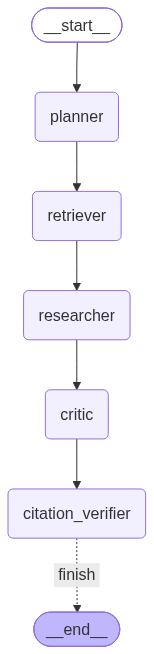

In [52]:
from IPython.display import Image, display

display(
    Image(
        research_graph.get_graph().draw_mermaid_png()
    )
)

In [53]:
import time
import pandas as pd

In [54]:
def create_evaluation_record(state, elapsed_time=None):

    docs = state.get("retrieved_docs", [])
    checks = state.get("citation_checks", [])

    supported = sum(
        1 for check in checks
        if check.supported
    )

    citation_total = len(checks)

    citation_support = (
        supported / citation_total
        if citation_total > 0
        else 0
    )

    pages = [
        doc.metadata.get("page")
        for doc in docs
    ]

    return {
        "question": state.get("question"),
        "documents_retrieved": len(docs),
        "unique_pages": len(set(pages)),
        "citation_checks": citation_total,
        "supported_citations": supported,
        "citation_support_score": round(
            citation_support, 3
        ),
        "retrieval_round": state.get(
            "retrieval_round", 0
        ),
        "response_time_seconds": elapsed_time
    }

In [55]:
record = create_evaluation_record(state)

print(record)

{'question': '\nCompare Retrieval-Augmented Generation with traditional\nlanguage models for knowledge-intensive NLP tasks.\n', 'documents_retrieved': 0, 'unique_pages': 0, 'citation_checks': 0, 'supported_citations': 0, 'citation_support_score': 0, 'retrieval_round': 0, 'response_time_seconds': None}


In [56]:
experiment_results = []

In [57]:
experiment_results.append(record)

evaluation_df = pd.DataFrame(
    experiment_results
)

evaluation_df

,question,documents_retrieved,unique_pages,citation_checks,supported_citations,citation_support_score,retrieval_round,response_time_seconds
0,\nCompare Retrieval-Augmented Generation with ...,0,0,0,0,0,0,None


In [58]:
def evaluate_retrieval(
    question,
    relevant_pages,
    k=3
):

    results = vector_store.similarity_search(
        question,
        k=k
    )

    retrieved_pages = [
        doc.metadata.get("page")
        for doc in results
    ]

    relevant_pages = set(relevant_pages)

    retrieved_relevant = sum(
        1
        for page in retrieved_pages
        if page in relevant_pages
    )

    precision = (
        retrieved_relevant / k
        if k > 0
        else 0
    )

    recall = (
        retrieved_relevant / len(relevant_pages)
        if relevant_pages
        else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall > 0
        else 0
    )

    return {
        "question": question,
        "retrieved_pages": retrieved_pages,
        "precision@3": round(precision, 3),
        "recall@3": round(recall, 3),
        "f1@3": round(f1, 3)
    }

In [59]:
for page_number, page in enumerate(pdf, 1):

    text = page.get_text()

    print("\n" + "=" * 70)
    print("PAGE:", page_number)
    print(text[:1000])

ValueError: document closed

In [60]:
import fitz

pdf_path = r"C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\data\research_papers\r1.pdf"

pdf = fitz.open(pdf_path)

print("Total pages:", len(pdf))

for page_number, page in enumerate(pdf, 1):

    text = page.get_text()

    print("\n" + "=" * 70)
    print("PAGE:", page_number)
    print(text[:1000])

Total pages: 19

PAGE: 1
Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research; ‡University College London; ⋆New York University;
plewis@fb.com
Abstract
Large pre-trained language models have been shown to store factual knowledge
in their parameters, and achieve state-of-the-art results when ﬁne-tuned on down-
stream NLP tasks. However, their ability to access and precisely manipulate knowl-
edge is still limited, and hence on knowledge-intensive tasks, their performance
lags behind task-speciﬁc architectures. Additionally, providing provenance for their
decisions and updating their world knowledge remain open research problems. Pre-
trained models with a differentiable access mechanism to explicit non-parametric
memory have so far been only investigated fo

In [61]:
for page_number, page in enumerate(pdf, 1):
    text = page.get_text().replace("\n", " ")
    
    print(f"\nPAGE {page_number}:")
    print(text[:250])


PAGE 1:
Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks Patrick Lewis†‡, Ethan Perez⋆, Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†, Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡

PAGE 2:
The Divine Comedy (x) q Query Encoder q(x) MIPS pθ Generator pθ (Parametric) Margin- alize This 14th century work is divided into 3 sections: "Inferno", "Purgatorio" & "Paradiso"         (y) End-to-End Backprop through q and pθ Barack Obama was born 

PAGE 3:
by θ that generates a current token based on a context of the previous i −1 tokens y1:i−1, the original input x and a retrieved passage z. To train the retriever and generator end-to-end, we treat the retrieved document as a latent variable. We propo

PAGE 4:
minimize the negative marginal log-likelihood of each target, P j −log p(yj|xj) using stochastic gradient descent with Adam [28]. Updating the document encoder BERTd during training is costly as it requires the 

In [62]:
test_questions = [
    {
        "question": "What limitations do pre-trained language models have when accessing and manipulating knowledge?",
        "relevant_pages": [1]
    },
    {
        "question": "Why is provenance for model decisions an important problem in knowledge-intensive NLP?",
        "relevant_pages": [1]
    },
    {
        "question": "How does Retrieval-Augmented Generation combine a retriever with a generator?",
        "relevant_pages": [2]
    },
    {
        "question": "What is the role of the document index in the RAG architecture?",
        "relevant_pages": [2]
    },
    {
        "question": "How does RAG retrieve information relevant to a query?",
        "relevant_pages": [2]
    }
]

print("Evaluation questions:", len(test_questions))

Evaluation questions: 5


In [63]:
evaluation_results = []

for item in test_questions:

    question = item["question"]
    relevant_pages = item["relevant_pages"]

    results = vector_store.similarity_search(
        question,
        k=3
    )

    retrieved_pages = [
        doc.metadata.get("page")
        for doc in results
    ]

    relevant_retrieved = sum(
        1
        for page in retrieved_pages
        if page in relevant_pages
    )

    precision = relevant_retrieved / 3

    recall = (
        relevant_retrieved / len(relevant_pages)
        if relevant_pages
        else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    evaluation_results.append({
        "question": question,
        "relevant_pages": relevant_pages,
        "retrieved_pages": retrieved_pages,
        "precision@3": round(precision, 3),
        "recall@3": round(recall, 3),
        "f1@3": round(f1, 3)
    })

In [64]:
evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,question,relevant_pages,retrieved_pages,precision@3,recall@3,f1@3
0,What limitations do pre-trained language model...,[1],"[1, 14, 1]",0.667,2.0,1.0
1,Why is provenance for model decisions an impor...,[1],"[1, 14, 14]",0.333,1.0,0.5
2,How does Retrieval-Augmented Generation combin...,[2],"[1, 7, 19]",0.000,0.0,0.0
3,What is the role of the document index in the ...,[2],"[18, 8, 17]",0.000,0.0,0.0
4,How does RAG retrieve information relevant to ...,[2],"[3, 8, 5]",0.000,0.0,0.0


In [65]:
print(
    "Average Precision@3:",
    round(evaluation_df["precision@3"].mean(), 3)
)

print(
    "Average Recall@3:",
    round(evaluation_df["recall@3"].mean(), 3)
)

print(
    "Average F1@3:",
    round(evaluation_df["f1@3"].mean(), 3)
)

Average Precision@3: 0.2
Average Recall@3: 0.6
Average F1@3: 0.3


In [66]:
print(evaluation_df.to_string(index=False))

                                                                                       question relevant_pages retrieved_pages  precision@3  recall@3  f1@3
What limitations do pre-trained language models have when accessing and manipulating knowledge?            [1]      [1, 14, 1]        0.667       2.0   1.0
         Why is provenance for model decisions an important problem in knowledge-intensive NLP?            [1]     [1, 14, 14]        0.333       1.0   0.5
                  How does Retrieval-Augmented Generation combine a retriever with a generator?            [2]      [1, 7, 19]        0.000       0.0   0.0
                                What is the role of the document index in the RAG architecture?            [2]     [18, 8, 17]        0.000       0.0   0.0
                                         How does RAG retrieve information relevant to a query?            [2]       [3, 8, 5]        0.000       0.0   0.0


In [67]:
print("\nAverage Precision@3:",
      round(evaluation_df["precision@3"].mean(), 3))

print("Average Recall@3:",
      round(evaluation_df["recall@3"].mean(), 3))

print("Average F1@3:",
      round(evaluation_df["f1@3"].mean(), 3))


Average Precision@3: 0.2
Average Recall@3: 0.6
Average F1@3: 0.3


In [68]:
%pip install rank_bm25

Note: you may need to restart the kernel to use updated packages.


In [69]:
from rank_bm25 import BM25Okapi

chunk_texts = [
    doc.page_content
    for doc in chunks
]

tokenized_corpus = [
    text.lower().split()
    for text in chunk_texts
]

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 index created.")

BM25 index created.


In [70]:
query = "What limitations do pre-trained language models have when accessing and manipulating knowledge?"

scores = bm25.get_scores(query.lower().split())

top_indices = sorted(
    range(len(scores)),
    key=lambda i: scores[i],
    reverse=True
)[:3]

for rank, index in enumerate(top_indices, 1):
    doc = chunks[index]

    print(f"\n--- Result {rank} ---")
    print("Page:", doc.metadata.get("page"))
    print("Chunk:", doc.metadata.get("chunk_id"))
    print(doc.page_content[:300])


--- Result 1 ---
Page: 1
Chunk: 3
per token. We ﬁne-tune and evaluate our models on a wide range of knowledge-
intensive NLP tasks and set the state of the art on three open domain QA tasks,
outperforming parametric seq2seq models and task-speciﬁc retrieve-and-extract
architectures. For language generation tasks, we ﬁnd that RAG mod

--- Result 2 ---
Page: 3
Chunk: 15
pre-trained using a denoising objective and a variety of different noising functions. It has obtained
state-of-the-art results on a diverse set of generation tasks and outperforms comparably-sized T5
models [32]. We refer to the BART generator parameters θ as the parametric memory henceforth.
2.4
Tr

--- Result 3 ---
Page: 1
Chunk: 1
Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research; ‡Uni

In [71]:
query = "What limitations do pre-trained language models have when accessing and manipulating knowledge?"

scores = bm25.get_scores(query.lower().split())

top_indices = sorted(
    range(len(scores)),
    key=lambda i: scores[i],
    reverse=True
)[:3]

for rank, index in enumerate(top_indices, 1):
    doc = chunks[index]

    print(f"\n--- Result {rank} ---")
    print("Page:", doc.metadata.get("page"))
    print("Chunk:", doc.metadata.get("chunk_id"))
    print(doc.page_content[:300])


--- Result 1 ---
Page: 1
Chunk: 3
per token. We ﬁne-tune and evaluate our models on a wide range of knowledge-
intensive NLP tasks and set the state of the art on three open domain QA tasks,
outperforming parametric seq2seq models and task-speciﬁc retrieve-and-extract
architectures. For language generation tasks, we ﬁnd that RAG mod

--- Result 2 ---
Page: 3
Chunk: 15
pre-trained using a denoising objective and a variety of different noising functions. It has obtained
state-of-the-art results on a diverse set of generation tasks and outperforms comparably-sized T5
models [32]. We refer to the BART generator parameters θ as the parametric memory henceforth.
2.4
Tr

--- Result 3 ---
Page: 1
Chunk: 1
Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research; ‡Uni

In [72]:
def hybrid_search(query, k=3, alpha=0.5):

    # Semantic retrieval
    semantic_docs = vector_store.similarity_search(
        query,
        k=k * 2
    )

    # BM25 retrieval
    scores = bm25.get_scores(
        query.lower().split()
    )

    top_indices = sorted(
        range(len(scores)),
        key=lambda i: scores[i],
        reverse=True
    )[:k * 2]

    keyword_docs = [
        chunks[i]
        for i in top_indices
    ]

    # Combine results
    combined = []

    for rank, doc in enumerate(semantic_docs):
        combined.append({
            "doc": doc,
            "score": alpha * (1 / (rank + 1))
        })

    for rank, doc in enumerate(keyword_docs):
        combined.append({
            "doc": doc,
            "score": (1 - alpha) * (1 / (rank + 1))
        })

    # Aggregate scores for duplicate chunks
    scores_by_id = {}

    for item in combined:

        doc = item["doc"]

        doc_id = (
            doc.metadata.get("source"),
            doc.metadata.get("page"),
            doc.metadata.get("chunk_id")
        )

        scores_by_id[doc_id] = (
            scores_by_id.get(doc_id, 0)
            + item["score"]
        )

    # Sort
    ranked_ids = sorted(
        scores_by_id,
        key=scores_by_id.get,
        reverse=True
    )[:k]

    # Recover documents
    doc_lookup = {}

    for doc in semantic_docs + keyword_docs:

        doc_id = (
            doc.metadata.get("source"),
            doc.metadata.get("page"),
            doc.metadata.get("chunk_id")
        )

        doc_lookup[doc_id] = doc

    return [
        doc_lookup[doc_id]
        for doc_id in ranked_ids
    ]

In [73]:
query = test_questions[0]["question"]

results = hybrid_search(query, k=3)

for i, doc in enumerate(results, 1):

    print(f"\n--- Hybrid Result {i} ---")
    print("Page:", doc.metadata.get("page"))
    print("Chunk:", doc.metadata.get("chunk_id"))
    print(doc.page_content[:300])


--- Hybrid Result 1 ---
Page: 1
Chunk: 1
Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research; ‡University 

--- Hybrid Result 2 ---
Page: 1
Chunk: 3
per token. We ﬁne-tune and evaluate our models on a wide range of knowledge-
intensive NLP tasks and set the state of the art on three open domain QA tasks,
outperforming parametric seq2seq models and task-speciﬁc retrieve-and-extract
architectures. For language generation tasks, we ﬁnd that RAG mod

--- Hybrid Result 3 ---
Page: 14
Chunk: 71
language-unsupervised/language_understanding_paper.pdf.
[50] Alec
Radford,
Jeff
Wu,
Rewon
Child,
David
Luan,
Dario
Amodei,
and
Ilya
Sutskever.
Language models are unsupervised multitask learners,
2019.
URL
https://d4mucfpksywv.cloudfront.net/better-language-models/langu

In [74]:
hybrid_results = []

for item in test_questions:

    question = item["question"]
    relevant_pages = set(item["relevant_pages"])

    results = hybrid_search(
        question,
        k=3
    )

    retrieved_pages = [
        doc.metadata.get("page")
        for doc in results
    ]

    relevant_retrieved = sum(
        1
        for page in retrieved_pages
        if page in relevant_pages
    )

    precision = relevant_retrieved / 3

    recall = (
        relevant_retrieved / len(relevant_pages)
        if relevant_pages
        else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall > 0
        else 0
    )

    hybrid_results.append({
        "question": question,
        "retrieved_pages": retrieved_pages,
        "precision@3": round(precision, 3),
        "recall@3": round(recall, 3),
        "f1@3": round(f1, 3)
    })

hybrid_df = pd.DataFrame(hybrid_results)

hybrid_df

,question,retrieved_pages,precision@3,recall@3,f1@3
0,What limitations do pre-trained language model...,"[1, 1, 14]",0.667,2.0,1.0
1,Why is provenance for model decisions an impor...,"[1, 14, 4]",0.333,1.0,0.5
2,How does Retrieval-Augmented Generation combin...,"[1, 2, 9]",0.333,1.0,0.5
3,What is the role of the document index in the ...,"[18, 7, 8]",0.000,0.0,0.0
4,How does RAG retrieve information relevant to ...,"[3, 7, 19]",0.000,0.0,0.0


In [75]:
print("BASELINE")
print(
    "Precision@3:",
    round(evaluation_df["precision@3"].mean(), 3)
)
print(
    "Recall@3:",
    round(evaluation_df["recall@3"].mean(), 3)
)
print(
    "F1@3:",
    round(evaluation_df["f1@3"].mean(), 3)
)

print("\nHYBRID")
print(
    "Precision@3:",
    round(hybrid_df["precision@3"].mean(), 3)
)
print(
    "Recall@3:",
    round(hybrid_df["recall@3"].mean(), 3)
)
print(
    "F1@3:",
    round(hybrid_df["f1@3"].mean(), 3)
)

BASELINE
Precision@3: 0.2
Recall@3: 0.6
F1@3: 0.3

HYBRID
Precision@3: 0.267
Recall@3: 0.8
F1@3: 0.4


In [76]:
def retriever_agent(state: ResearchState):

    sub_questions = state["sub_questions"]

    all_documents = []

    for sub_question in sub_questions:

        results = hybrid_search(
            sub_question,
            k=3
        )

        all_documents.extend(results)

    # Remove duplicate chunks
    unique_documents = []
    seen = set()

    for doc in all_documents:

        identifier = (
            doc.metadata.get("source"),
            doc.metadata.get("page"),
            doc.metadata.get("chunk_id")
        )

        if identifier not in seen:
            seen.add(identifier)
            unique_documents.append(doc)

    return {
        "retrieved_docs": unique_documents
    }

In [77]:
retrieval_result = retriever_agent(state)

state["retrieved_docs"] = retrieval_result["retrieved_docs"]

print(
    "Documents retrieved:",
    len(state["retrieved_docs"])
)

Documents retrieved: 0


In [78]:
for i, doc in enumerate(state["retrieved_docs"], 1):

    print(
        f"{i}. "
        f"Page={doc.metadata.get('page')} | "
        f"Chunk={doc.metadata.get('chunk_id')}"
    )

In [79]:
for i, doc in enumerate(state["retrieved_docs"], 1):
    print(f"\n--- Document {i} ---")
    print("Source:", doc.metadata.get("source"))
    print("Page:", doc.metadata.get("page"))
    print("Chunk:", doc.metadata.get("chunk_id"))
    print("Text:", doc.page_content[:250])

In [80]:
test_state = {
    "question": "How does Retrieval-Augmented Generation improve knowledge-intensive NLP tasks?",
    "plan": "",
    "sub_questions": [],
    "retrieved_docs": [],
    "answer": "",
    "critique": "",
    "needs_retrieval": False,
    "retrieval_round": 0,
    "citation_checks": []
}

In [81]:
planner_result = planner_agent(test_state)

test_state.update(planner_result)

print("PLAN:")
print(test_state["plan"])

print("\nSUB-QUESTIONS:")
for q in test_state["sub_questions"]:
    print("-", q)

C:\Users\lenovo\Desktop\Agentic-RAG-Research-Assistant\rag_env\Lib\site-packages\langchain_google_genai\chat_models.py:3610: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


PLAN:
[{'type': 'text', 'text': '### Research Question Analysis\n\n**1. What information needs to be retrieved?**\n* **Definitions & Context:** Clear definitions of Retrieval-Augmented Generation (RAG) and "knowledge-intensive NLP tasks" (e.g., open-domain question answering, fact verification, dialogue generation).\n* **Architectural Mechanics:** Information on how RAG integrates non-parametric memory (external retriever) with parametric memory (generative language model).\n* **Empirical Data:** Quantitative benchmark performance (e.g., Exact Match, F1 scores on datasets like Natural Questions, TriviaQA, FEVER) comparing RAG architectures against purely parametric models.\n* **Qualitative Improvements:** Evidence regarding hallucination reduction, knowledge recency/updating capabilities, context provenance, and interpretability.\n\n**2. Single or Multiple Pieces of Evidence?**\n* **Multiple pieces of evidence.** Assessing how RAG improves tasks requires synthesized evidence across dif

In [82]:
retrieval_result = retriever_agent(test_state)

test_state.update(retrieval_result)

print("Documents retrieved:", len(test_state["retrieved_docs"]))

Documents retrieved: 0


In [83]:
for i, doc in enumerate(test_state["retrieved_docs"], 1):
    print(
        f"{i}. "
        f"Page={doc.metadata.get('page')} | "
        f"Chunk={doc.metadata.get('chunk_id')}"
    )